# Seasonal Agriculture Performance Analysis

**Objective:** Analyze crop performance across seasons, crops, states, irrigation methods, environmental conditions, resource usage, revenue, cost, profit, water efficiency, and disease/pest risk using the provided agriculture dataset.


## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## Step 2: Load the Dataset


In [2]:
# Upload DOC-20260906-WA0002.csv to Google Colab, then run this cell
df = pd.read_csv("DOC-20260906-WA0002.csv")

df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## Step 3 — Understand the Dataset


In [3]:
df.shape


(4000, 28)

In [4]:
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [5]:
df.columns


Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [8]:
print("Seasons:")
print(df["Season"].unique())

print("\nStates:")
print(df["State"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].unique())


Seasons:
['Kharif' 'Rabi' 'Zaid']

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [9]:
print("Number of unique farms:", df["Farm_ID"].nunique())
print("Number of states:", df["State"].nunique())
print("Number of districts:", df["District"].nunique())
print("Number of crops:", df["Crop"].nunique())
print("Number of seasons:", df["Season"].nunique())


Number of unique farms: 4000
Number of states: 8
Number of districts: 10
Number of crops: 8
Number of seasons: 3


## Step 4 — Clean the Dataset


In [10]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()
df.columns


Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [11]:
# Check missing values
df.isnull().sum()


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [12]:
# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [13]:
# Standardize text columns
text_columns = ["Farm_ID", "State", "District", "Crop", "Season", "Irrigation_Method"]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

# Check unique categorical values after cleaning
for column in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{column}:")
    print(df[column].unique())



State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [14]:
# Convert numeric columns to numeric type
numeric_columns = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha", "Production_Tonnes",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Profit_INR", "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df.dtypes)


Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [15]:
# Check missing values again after type conversion
print("Missing values after cleaning:")
print(df.isnull().sum())

# Check negative values in numeric columns
print("\nNegative values:")
for column in numeric_columns:
    count = (df[column] < 0).sum()
    if count > 0:
        print(column, ":", count)


Missing values after cleaning:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [16]:
# Create useful derived metrics
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)

df["Revenue_per_Hectare_INR"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Revenue_INR"] / df["Farm_Area_Hectares"],
    np.nan
)

df["Profit_per_Hectare_INR"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Profit_INR"] / df["Farm_Area_Hectares"],
    np.nan
)

df["Cost_per_Hectare_INR"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Total_Cost_INR"] / df["Farm_Area_Hectares"],
    np.nan
)

df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Hectare_INR,Profit_per_Hectare_INR,Cost_per_Hectare_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"58,132.08","-22,362.26","80,494.34"
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","6,186.98","-69,211.33","75,398.32"
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"39,190.53","-25,667.49","64,858.02"
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"44,608.89","-21,267.56","65,876.44"
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"45,987.41","-34,287.89","80,275.30"


## Step 5 — Exploratory Data Analysis (EDA) & Data Visualization


### Step 5.1: Overall Agriculture Performance


In [17]:
print("Total Farm Area (hectares):", df["Farm_Area_Hectares"].sum())
print("Total Production (tonnes):", df["Production_Tonnes"].sum())
print("Total Revenue (INR):", df["Revenue_INR"].sum())
print("Total Cost (INR):", df["Total_Cost_INR"].sum())
print("Total Profit (INR):", df["Profit_INR"].sum())
print("Average Yield (tonnes/ha):", df["Yield_Tonnes_Ha"].mean())
print("Average Profit Margin (%):", df["Profit_Margin_pct"].mean())
print("Average Water Efficiency:", df["Water_Efficiency_t_per_1000m3"].mean())


Total Farm Area (hectares): 31553.059999999998
Total Production (tonnes): 172984.84000000003
Total Revenue (INR): 2551440192
Total Cost (INR): 2105214332
Total Profit (INR): 446225860
Average Yield (tonnes/ha): 5.270594758064516
Average Profit Margin (%): -45.49217839680511
Average Water Efficiency: 5.385214249999999


### Step 5.2: Season-wise Analysis


In [18]:
season_analysis = df.groupby("Season").agg(
    Total_Area_Hectares=("Farm_Area_Hectares", "sum"),
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Total_Revenue_INR=("Revenue_INR", "sum"),
    Total_Cost_INR=("Total_Cost_INR", "sum"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Total_Profit_INR", ascending=False)

season_analysis


,Total_Area_Hectares,Total_Production_Tonnes,Total_Revenue_INR,Total_Cost_INR,Total_Profit_INR,Average_Yield,Average_Water_Efficiency
Season,,,,,,,
Kharif,"14,134.02","82,387.61",1264369200,946080042,318289158,5.64,5.89
Rabi,"12,612.84","67,498.88",978682881,836012113,142670768,5.08,5.19
Zaid,"4,806.20","23,098.35",308388111,323122177,-14734066,4.67,4.41


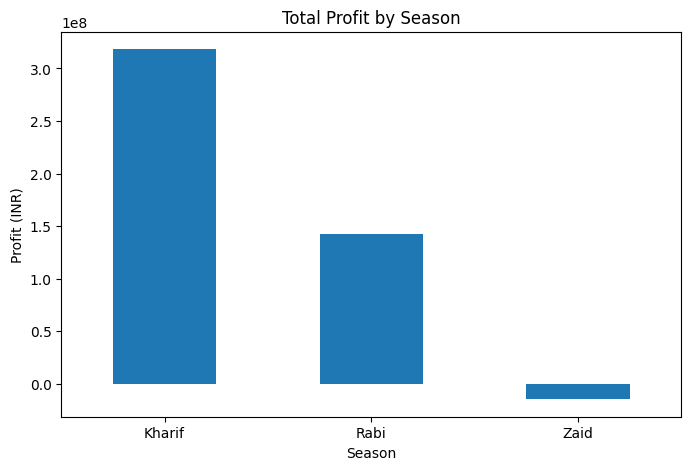

In [19]:
season_analysis["Total_Profit_INR"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Profit by Season"
)

plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=0)
plt.show()


### Step 5.3: Crop-wise Analysis


In [20]:
crop_analysis = df.groupby("Crop").agg(
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Total_Revenue_INR=("Revenue_INR", "sum"),
    Total_Cost_INR=("Total_Cost_INR", "sum"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Market_Price=("Market_Price_INR_Tonne", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Total_Profit_INR", ascending=False)

crop_analysis


,Total_Production_Tonnes,Total_Revenue_INR,Total_Cost_INR,Total_Profit_INR,Average_Yield,Average_Market_Price,Average_Disease_Risk
Crop,,,,,,,
Chilli,"5,101.75",526032218,216670341,309361877,1.54,"103,372.94",46.06
Sugarcane,"119,685.97",418453935,169211599,249242336,46.94,"3,490.25",45.40
Cotton,"4,773.10",324826926,261557093,63269833,1.23,"67,921.11",45.97
Groundnut,"4,094.07",230204651,211184808,19019843,1.32,"56,310.06",46.29
Pulses,"3,671.10",262119070,264221144,-2102074,0.92,"71,431.61",46.57
Maize,"12,001.40",251844463,298116521,-46272058,2.72,"20,990.55",45.54
Rice,"13,309.15",292294529,362821847,-70527318,2.44,"22,023.13",46.50
Wheat,"10,348.30",245664400,321430979,-75766579,2.11,"23,829.43",47.85


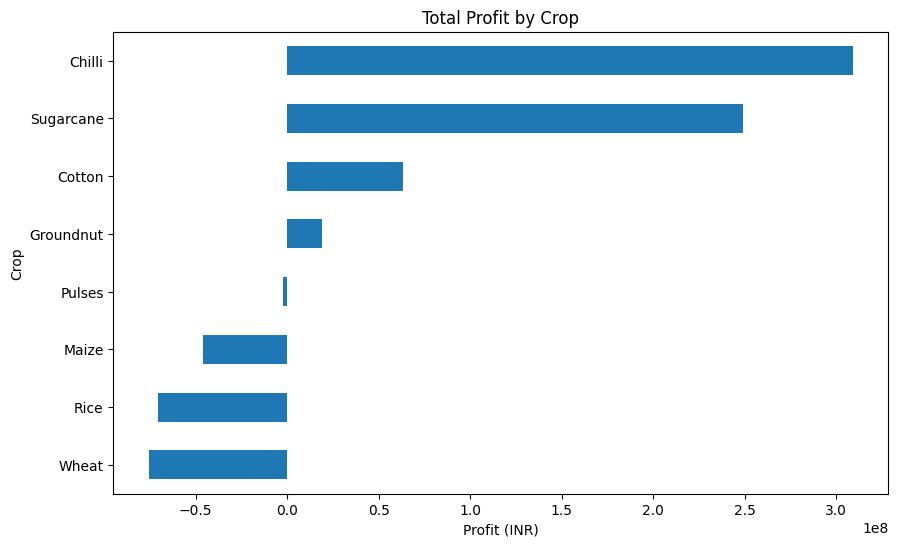

In [21]:
crop_analysis["Total_Profit_INR"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Total Profit by Crop"
)

plt.xlabel("Profit (INR)")
plt.ylabel("Crop")
plt.show()


### Step 5.4: State-wise Analysis


In [22]:
state_analysis = df.groupby("State").agg(
    Total_Area_Hectares=("Farm_Area_Hectares", "sum"),
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Total_Revenue_INR=("Revenue_INR", "sum"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Yield=("Yield_Tonnes_Ha", "mean")
).sort_values("Total_Profit_INR", ascending=False)

state_analysis


,Total_Area_Hectares,Total_Production_Tonnes,Total_Revenue_INR,Total_Profit_INR,Average_Yield
State,,,,,
Maharashtra,"3,949.49","22,519.83",332816727,69339574,5.03
Punjab,"3,982.46","25,280.82",332133240,65836408,6.12
Karnataka,"3,914.30","23,341.30",319525403,58397522,5.73
Gujarat,"3,899.60","23,586.01",319490116,57373299,5.70
Tamil Nadu,"3,714.63","19,807.58",305110307,57106203,4.90
Telangana,"4,027.78","20,255.16",324452819,56156082,5.08
Madhya Pradesh,"3,832.44","18,667.08",296986504,43159856,5.03
Andhra Pradesh,"4,232.36","19,527.06",320925076,38856916,4.65


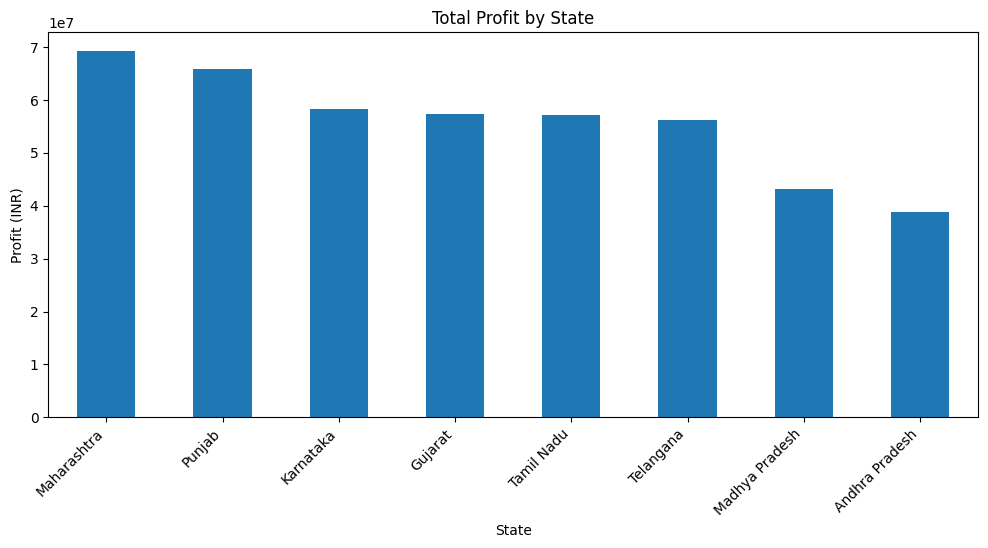

In [23]:
state_analysis["Total_Profit_INR"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Total Profit by State"
)

plt.xlabel("State")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.show()


### Step 5.5: Irrigation Method Analysis


In [24]:
irrigation_analysis = df.groupby("Irrigation_Method").agg(
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Total_Profit_INR", ascending=False)

irrigation_analysis


,Total_Production_Tonnes,Total_Profit_INR,Average_Yield,Average_Water_Used_m3,Average_Water_Efficiency
Irrigation_Method,,,,,
Drip,"53,064.77",200957788,6.62,"5,918.75",6.27
Flood,"50,738.41",96093770,4.90,"8,026.47",3.44
Rainfed,"38,105.84",82291430,4.61,"3,549.55",7.56
Sprinkler,"31,075.82",66882872,5.19,"6,208.26",4.67


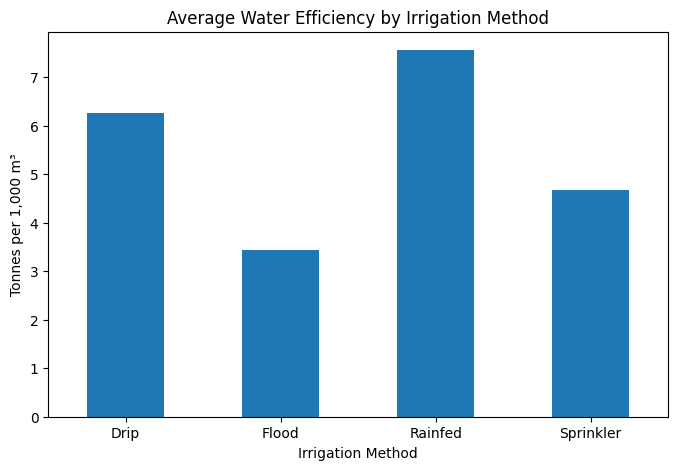

In [25]:
irrigation_analysis["Average_Water_Efficiency"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Water Efficiency by Irrigation Method"
)

plt.xlabel("Irrigation Method")
plt.ylabel("Tonnes per 1,000 m³")
plt.xticks(rotation=0)
plt.show()


### Step 5.6: Yield Analysis


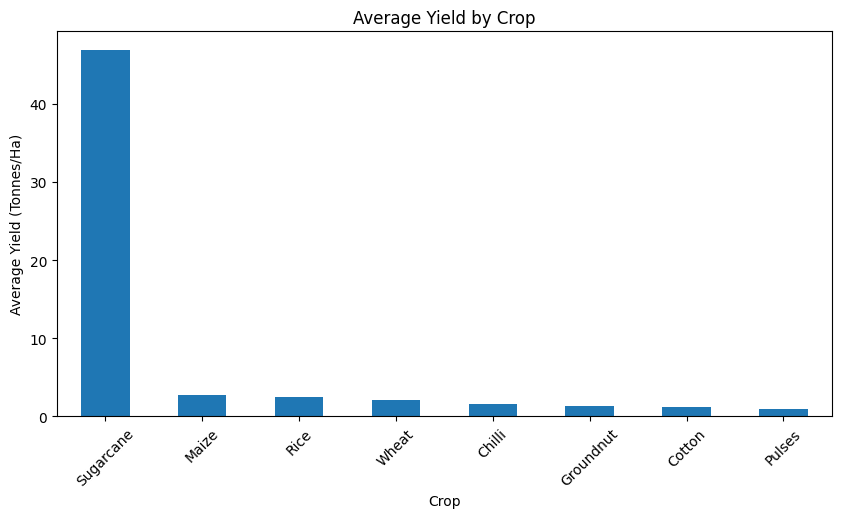

In [26]:
yield_by_crop = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

yield_by_crop.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Yield by Crop"
)

plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()


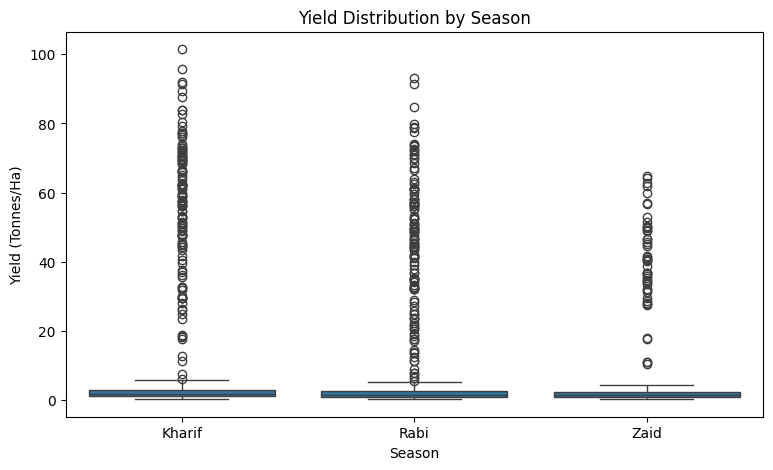

In [27]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")

plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


### Step 5.7: Top 10 Most Profitable Farms


In [28]:
top_10_profit = df.nlargest(10, "Profit_INR")

top_10_profit[[
    "Farm_ID", "State", "District", "Crop", "Season",
    "Yield_Tonnes_Ha", "Revenue_INR", "Total_Cost_INR", "Profit_INR"
]]


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,712027,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,1059050,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,745161,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,784135,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,1283161,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,972119,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,1097878,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,875331,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,844264,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,828217,3159447


### Step 5.8: Loss-making Farms


In [29]:
loss_making = df[df["Profit_INR"] < 0]

loss_making[[
    "Farm_ID", "State", "District", "Crop", "Season",
    "Revenue_INR", "Total_Cost_INR", "Profit_INR"
]].head(10)


,Farm_ID,State,District,Crop,Season,Revenue_INR,Total_Cost_INR,Profit_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,30810,42662,-11852
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,40401,492351,-451950
2,SF10003,Telangana,Warangal,Pulses,Rabi,190466,315210,-124744
3,SF10004,Telangana,Indore,Rice,Kharif,200740,296444,-95704
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,193607,337959,-144352
5,SF10006,Gujarat,Raichur,Pulses,Zaid,269570,302333,-32763
6,SF10007,Telangana,Warangal,Wheat,Rabi,472102,513341,-41239
10,SF10011,Maharashtra,Krishna,Wheat,Rabi,140857,289759,-148902
11,SF10012,Telangana,Rajkot,Maize,Rabi,385097,964512,-579415
12,SF10013,Punjab,Indore,Wheat,Rabi,42063,335153,-293090


In [30]:
print("Number of loss-making farms:", len(loss_making))
print("Total Loss (INR):", loss_making["Profit_INR"].sum())
print("Percentage of loss-making farms:", round(len(loss_making) / len(df) * 100, 2), "%")


Number of loss-making farms: 1966
Total Loss (INR): -424194190
Percentage of loss-making farms: 49.15 %


### Step 5.9: Environmental Conditions vs Yield


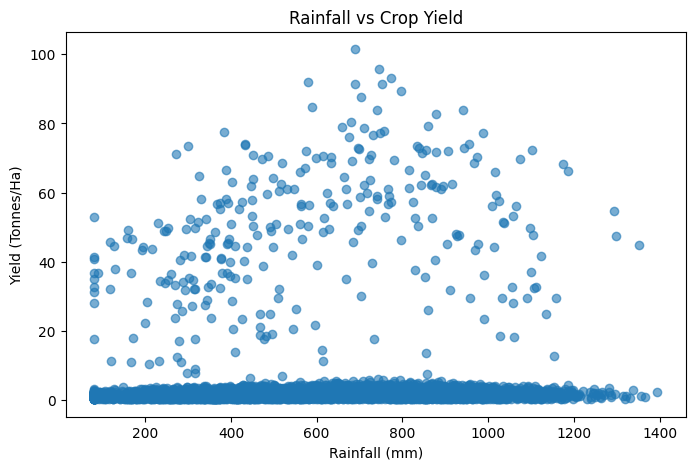

Rainfall-Yield Correlation: 0.03


In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

print(
    "Rainfall-Yield Correlation:",
    round(df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"]), 2)
)


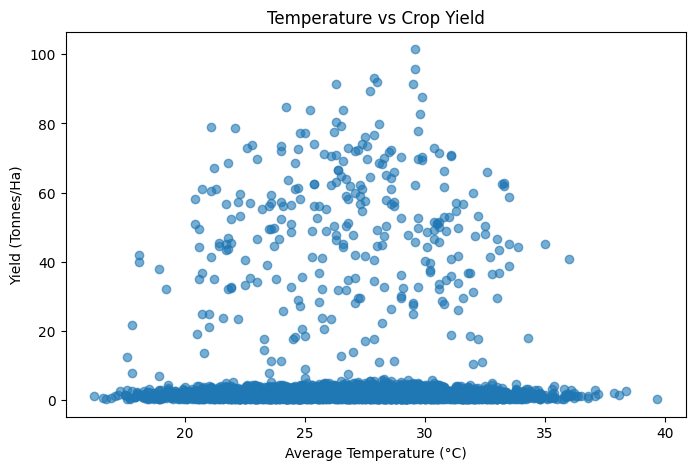

Temperature-Yield Correlation: 0.01


In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Avg_Temperature_C"],
    df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

print(
    "Temperature-Yield Correlation:",
    round(df["Avg_Temperature_C"].corr(df["Yield_Tonnes_Ha"]), 2)
)


### Step 5.10: Soil and Fertilizer Analysis


In [33]:
soil_analysis = df.groupby("Crop").agg(
    Average_Soil_pH=("Soil_pH", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
    Average_Nitrogen=("Nitrogen_kg_ha", "mean"),
    Average_Phosphorus=("Phosphorus_kg_ha", "mean"),
    Average_Potassium=("Potassium_kg_ha", "mean"),
    Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Average_Yield=("Yield_Tonnes_Ha", "mean")
).sort_values("Average_Yield", ascending=False)

soil_analysis


,Average_Soil_pH,Average_Soil_Moisture,Average_Nitrogen,Average_Phosphorus,Average_Potassium,Average_Fertilizer,Average_Yield
Crop,,,,,,,
Sugarcane,6.62,25.94,122.18,59.37,104.72,184.29,46.94
Maize,6.71,26.44,121.69,57.80,105.25,191.32,2.72
Rice,6.67,26.65,119.92,57.79,104.73,185.51,2.44
Wheat,6.72,26.65,121.52,57.93,105.10,183.21,2.11
Chilli,6.68,26.90,120.01,58.64,106.41,188.73,1.54
Groundnut,6.73,26.44,119.74,56.16,103.48,186.64,1.32
Cotton,6.72,26.16,116.89,57.17,103.05,185.42,1.23
Pulses,6.72,26.63,120.44,57.90,105.34,183.34,0.92


### Step 5.11: Water Usage and Efficiency


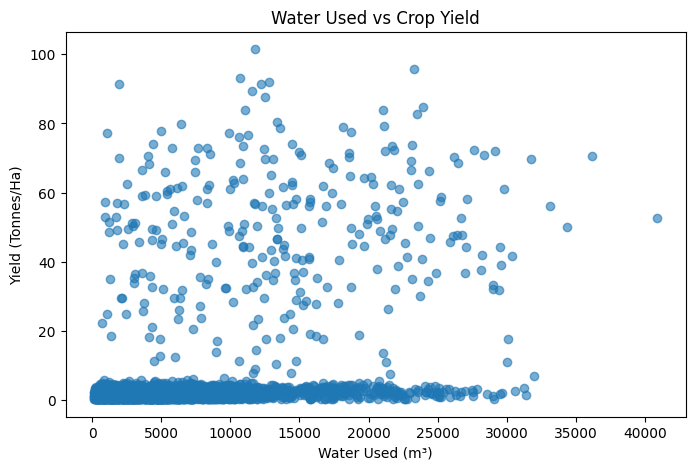

Water Used-Yield Correlation: 0.39


In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Water_Used_m3"],
    df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Water Used vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

print(
    "Water Used-Yield Correlation:",
    round(df["Water_Used_m3"].corr(df["Yield_Tonnes_Ha"]), 2)
)


In [35]:
water_by_crop = df.groupby("Crop").agg(
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Average_Water_Efficiency", ascending=False)

water_by_crop


,Average_Water_Used_m3,Average_Water_Efficiency
Crop,,
Sugarcane,"13,897.70",30.48
Maize,"4,377.78",5.60
Wheat,"4,054.40",4.63
Groundnut,"3,459.54",3.15
Chilli,"4,577.47",2.95
Pulses,"2,833.67",2.90
Rice,"10,920.22",1.95
Cotton,"5,410.86",1.94


### Step 5.12: Disease/Pest Risk Analysis


In [36]:
risk_by_crop = df.groupby("Crop").agg(
    Average_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values("Average_Disease_Pest_Risk", ascending=False)

risk_by_crop


,Average_Disease_Pest_Risk,Average_Yield,Average_Profit
Crop,,,
Wheat,47.85,2.11,"-123,398.34"
Pulses,46.57,0.92,"-4,238.05"
Rice,46.50,2.44,"-102,213.50"
Groundnut,46.29,1.32,"44,858.12"
Chilli,46.06,1.54,"750,878.34"
Cotton,45.97,1.23,"124,546.92"
Maize,45.54,2.72,"-83,978.33"
Sugarcane,45.40,46.94,"817,187.99"


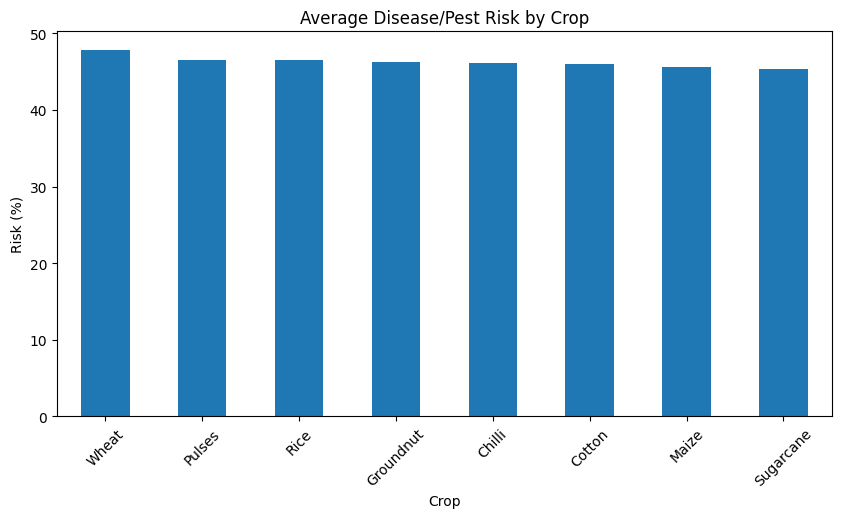

In [37]:
risk_by_crop["Average_Disease_Pest_Risk"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Disease/Pest Risk by Crop"
)

plt.xlabel("Crop")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.show()


### Step 5.13: Revenue vs Profit


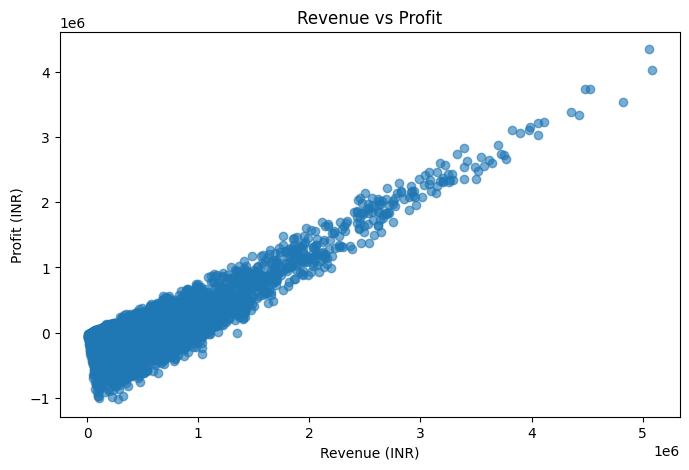

Revenue-Profit Correlation: 0.89


In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Revenue_INR"],
    df["Profit_INR"],
    alpha=0.6
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue (INR)")
plt.ylabel("Profit (INR)")
plt.show()

print(
    "Revenue-Profit Correlation:",
    round(df["Revenue_INR"].corr(df["Profit_INR"]), 2)
)


### Step 5.14: Correlation Analysis


In [39]:
numeric_data = df.select_dtypes(include="number")
correlation_matrix = numeric_data.corr()

correlation_matrix


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Hectare_INR,Profit_per_Hectare_INR,Cost_per_Hectare_INR
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03,-0.00,0.02,0.02,0.01
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63,0.06,0.13,0.12,0.03
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25,-0.01,0.01,0.01,0.02
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55,0.03,0.08,0.08,0.02
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25,-0.04,-0.06,-0.06,-0.01
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03,-0.01,-0.01,-0.01,-0.01
Soil_Moisture_pct,0.00,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38,0.05,0.11,0.11,0.00
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01,0.04,0.09,0.09,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03,0.05,0.07,0.07,-0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01,0.01,0.03,0.03,0.00


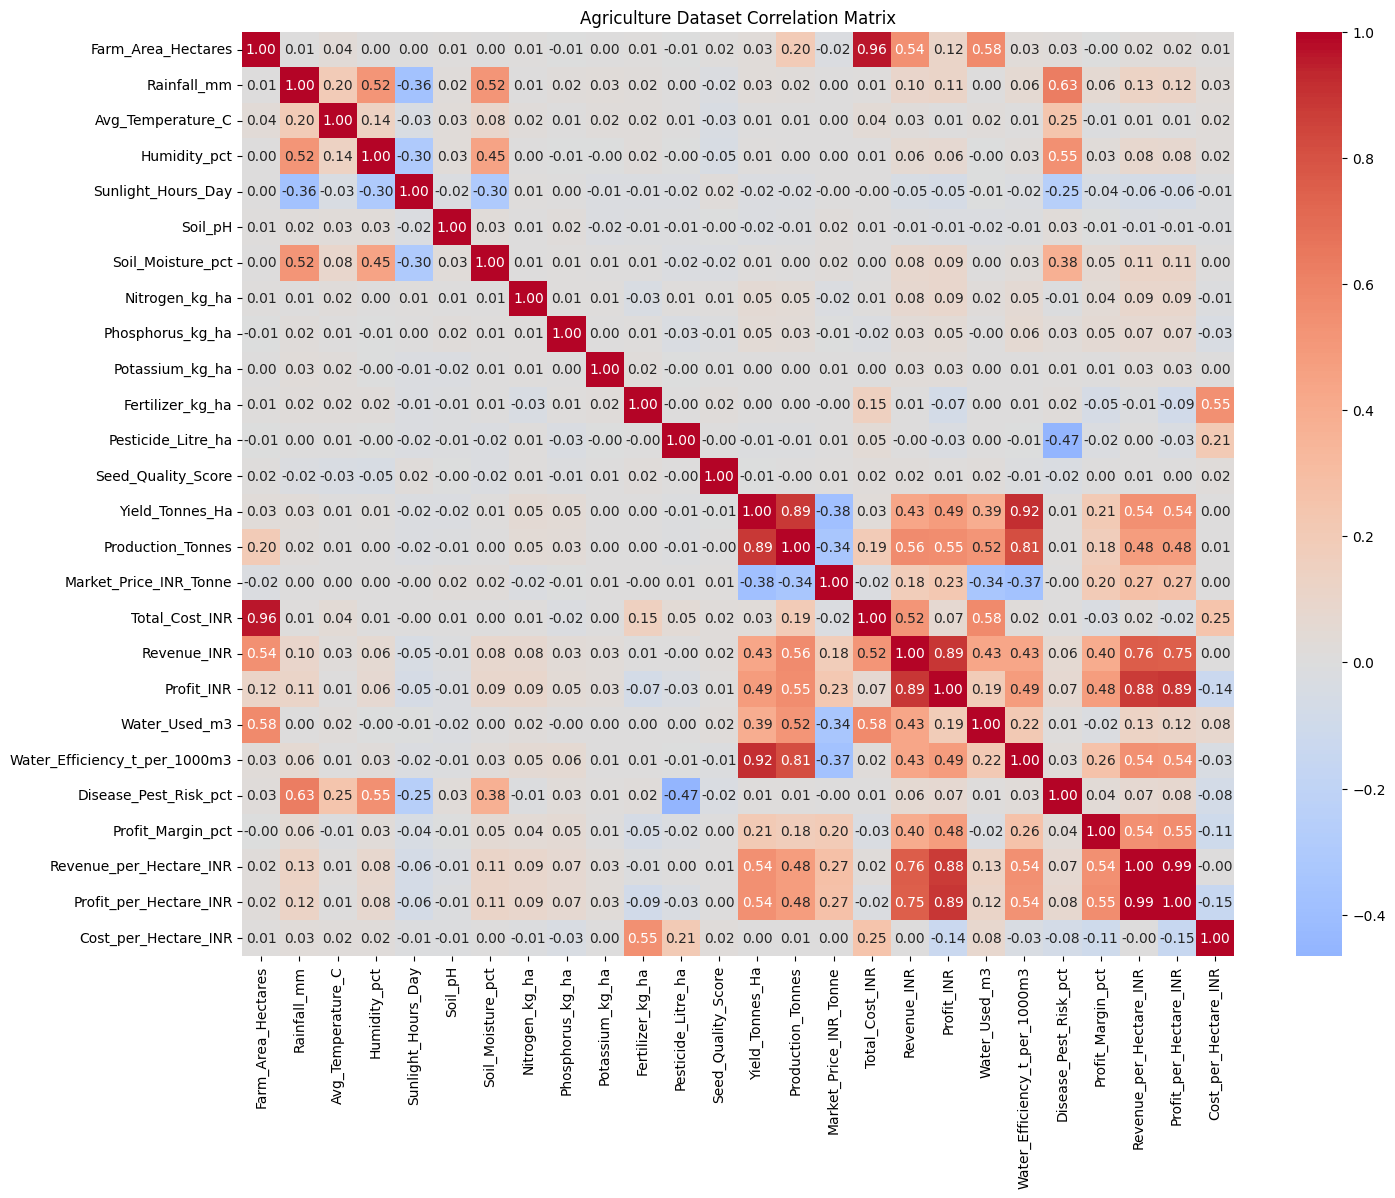

In [40]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Agriculture Dataset Correlation Matrix")
plt.show()


## Step 6 — Key Performance Indicators (KPIs)


In [41]:
kpis = {
    "Total Farms": df["Farm_ID"].nunique(),
    "Total Farm Area (Ha)": df["Farm_Area_Hectares"].sum(),
    "Total Production (Tonnes)": df["Production_Tonnes"].sum(),
    "Total Revenue (INR)": df["Revenue_INR"].sum(),
    "Total Cost (INR)": df["Total_Cost_INR"].sum(),
    "Total Profit (INR)": df["Profit_INR"].sum(),
    "Average Yield (Tonnes/Ha)": df["Yield_Tonnes_Ha"].mean(),
    "Average Disease/Pest Risk (%)": df["Disease_Pest_Risk_pct"].mean(),
    "Average Water Efficiency": df["Water_Efficiency_t_per_1000m3"].mean()
}

for key, value in kpis.items():
    print(f"{key}: {value:,.2f}")


Total Farms: 4,000.00
Total Farm Area (Ha): 31,553.06
Total Production (Tonnes): 172,984.84
Total Revenue (INR): 2,551,440,192.00
Total Cost (INR): 2,105,214,332.00
Total Profit (INR): 446,225,860.00
Average Yield (Tonnes/Ha): 5.27
Average Disease/Pest Risk (%): 46.37
Average Water Efficiency: 5.39


## Step 7 — Business / Agricultural Insights


In [42]:
# Step 7.1: Best season by profit
top_season = season_analysis["Total_Profit_INR"].idxmax()
top_season_profit = season_analysis["Total_Profit_INR"].max()

print("Best Season by Profit:", top_season)
print("Total Profit:", top_season_profit)


Best Season by Profit: Kharif
Total Profit: 318289158


In [43]:
# Step 7.2: Most profitable crop
top_crop = crop_analysis["Total_Profit_INR"].idxmax()
top_crop_profit = crop_analysis["Total_Profit_INR"].max()

print("Most Profitable Crop:", top_crop)
print("Total Profit:", top_crop_profit)


Most Profitable Crop: Chilli
Total Profit: 309361877


In [44]:
# Step 7.3: Best performing state by profit
top_state = state_analysis["Total_Profit_INR"].idxmax()
top_state_profit = state_analysis["Total_Profit_INR"].max()

print("Best Performing State:", top_state)
print("Total Profit:", top_state_profit)


Best Performing State: Maharashtra
Total Profit: 69339574


In [45]:
# Step 7.4: Best irrigation method by average water efficiency
best_irrigation = irrigation_analysis["Average_Water_Efficiency"].idxmax()
best_water_efficiency = irrigation_analysis["Average_Water_Efficiency"].max()

print("Most Water-Efficient Irrigation Method:", best_irrigation)
print("Average Water Efficiency:", best_water_efficiency)


Most Water-Efficient Irrigation Method: Rainfed
Average Water Efficiency: 7.56378386167147


In [46]:
# Step 7.5: Highest-yielding crop
highest_yield_crop = yield_by_crop.idxmax()
highest_yield = yield_by_crop.max()

print("Highest Average Yield Crop:", highest_yield_crop)
print("Average Yield (Tonnes/Ha):", highest_yield)


Highest Average Yield Crop: Sugarcane
Average Yield (Tonnes/Ha): 46.93874587458746


In [47]:
# Step 7.6: Highest-risk crop
highest_risk_crop = risk_by_crop["Average_Disease_Pest_Risk"].idxmax()
highest_risk = risk_by_crop["Average_Disease_Pest_Risk"].max()

print("Highest Disease/Pest Risk Crop:", highest_risk_crop)
print("Average Risk (%):", highest_risk)


Highest Disease/Pest Risk Crop: Wheat
Average Risk (%): 47.85472312703583


In [48]:
# Step 7.7: Loss-making farms
print("Loss-Making Farms:", len(loss_making))
print("Total Loss (INR):", loss_making["Profit_INR"].sum())


Loss-Making Farms: 1966
Total Loss (INR): -424194190


## Step 8 — Export the Cleaned Dataset


In [49]:
# Final dataset check
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Final dataset shape: (4000, 32)

Missing values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficienc

In [50]:
# Export cleaned dataset
df.to_csv("cleaned_seasonal_agriculture_data.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [51]:
# Verify exported dataset
cleaned_df = pd.read_csv("cleaned_seasonal_agriculture_data.csv")

print("Shape:", cleaned_df.shape)
cleaned_df.head()


Shape: (4000, 32)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Revenue_per_Hectare_INR,Profit_per_Hectare_INR,Cost_per_Hectare_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"58,132.08","-22,362.26","80,494.34"
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","6,186.98","-69,211.33","75,398.32"
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"39,190.53","-25,667.49","64,858.02"
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"44,608.89","-21,267.56","65,876.44"
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"45,987.41","-34,287.89","80,275.30"


## Final Conclusions

The Seasonal Agriculture Performance Analysis provides useful insights into how agricultural performance varies across seasons, crops, regions, irrigation methods, environmental conditions, resource usage and economic factors.

### Key Findings

* **Kharif season shows the best overall performance**, with the highest average yield and average profit among the three seasons. It also contributes the highest total production.

* **Rabi season shows moderate performance**, with lower average profit and yield compared with Kharif but better economic performance than Zaid.

* **Zaid season shows the weakest economic performance**, with the lowest average yield and a negative average profit. This indicates that better crop selection, irrigation planning and cost management may be required during this season.

* **Crop selection has a major effect on agricultural profitability.** Sugarcane and Chilli show the highest average profits, while Wheat, Rice and Maize have negative average profits in the analyzed dataset.

* **Irrigation method affects agricultural performance.** Farms using Drip irrigation show the highest average yield and profit among the irrigation methods analyzed.

* **Flood irrigation has the highest average water usage**, indicating that it may require better water-management practices to improve resource efficiency.

* **Water efficiency has a very strong positive relationship with yield.** This indicates that farms using water more efficiently tend to achieve higher yields in the dataset.

* **Production and yield have a strong positive relationship**, showing that higher productivity per hectare is generally associated with higher total production.

* **Yield is positively related to revenue and profit**, indicating that improved agricultural productivity is generally associated with better economic outcomes.

* **Market price shows a negative relationship with yield** in the analyzed data. However, this relationship represents correlation and does not establish a direct cause-and-effect relationship.

* **Disease and pest risk varies across seasons.** Kharif has the highest average disease/pest risk, while Zaid has the lowest average risk.

* **Environmental conditions vary significantly between seasons.** Kharif receives considerably higher rainfall, while Zaid experiences higher temperatures and lower rainfall.

### Overall Conclusion

The analysis shows that **season, crop selection, irrigation method and resource efficiency are important factors associated with agricultural performance**. Kharif appears to be the most productive and profitable season, while Zaid requires greater attention from an economic and resource-management perspective.

The results also highlight the importance of selecting suitable crops, adopting efficient irrigation methods and improving water-use efficiency. These insights can help support **better seasonal agricultural planning, resource allocation and crop-selection decisions**.

Overall, the analysis demonstrates how **data analysis and visualization can be used to identify seasonal patterns, compare agricultural performance, detect variations and generate evidence-based recommendations for agricultural planning.**

> **Note:** The conclusions are based on patterns and relationships observed in the available dataset. Correlation does not necessarily imply causation.
